### Import packages

In [1]:
%matplotlib inline

import pathlib

import matplotlib.pyplot as plt
import numpy as np
import tsam

from ethos_tised import SolarModel

### Load the hourly resolution data to downscale

In [2]:
current_dir = pathlib.Path.cwd().parent
path_to_hourly_data = current_dir.joinpath(
    "Examples", "hourly_data", "Berlin.csv")

hourly_irrad_m = np.genfromtxt(
    path_to_hourly_data,
    delimiter=",",
)

### Calling the SolarModel of ETHOS.TISED to downscale the hourly data to one minute

#### This requires the latitude, longitude, date, and data as inputs

In [3]:
synthetic = SolarModel(Lat=52.455778, Lon=13.523917, date=2018, data=hourly_irrad_m)

Timezone: Europe/Berlin
Start: 2018-01-01 00:00:00+01:00
End: 2018-12-31 23:59:00+01:00
The provided hourly GHI data has no missing values. Proceeding with original data.
Structured hourly data shape: (8760, 3)
Detected Köppen-Geiger Zone: Cfb
Mapped Climate Zone: Cfb
Using cached file: C:\Users\o.omoyele\.ethos_tised\data\Cfb\input_knn.csv
Using cached file: C:\Users\o.omoyele\.ethos_tised\data\Cfb\minutal_new.csv
                 day  synthetic_ghi
count  525600.000000  525600.000000
mean      183.000000     137.460745
std       105.366129     229.251564
min         1.000000       0.000000
25%        92.000000       0.000000
50%       183.000000       0.000000
75%       274.000000     185.035931
max       365.000000    1218.566708


### Aggregating the synthetic output into typical periods with tsam

The synthetic series covers a full year at one-minute resolution (525,600 rows), which can be too large to feed directly into an energy system optimization model. [tsam](https://github.com/FZJ-IEK3-VSA/tsam) reduces it to a small number of representative typical periods.

`synthetic` carries its timestamps in the `date` column rather than as the index, so that column must be set as the index before calling `tsam.aggregate` -- tsam needs a `DatetimeIndex` to know the data's time resolution. If a plain integer index is passed instead, tsam does not raise an error; it silently assumes hourly-resolution data, which quietly produces wrong results for this minute-resolution series.

In [ ]:
from tsam import aggregate, ClusterConfig, SegmentConfig, ExtremeConfig

ghi = synthetic.set_index("date")[["synthetic_ghi"]]

aggregated = tsam.aggregate(
    ghi,
    n_clusters=365,
    period_duration="1D",
    cluster=ClusterConfig(
        method='hierarchical',
        representation='distribution_minmax'
        ),
    segments=SegmentConfig(n_segments=24),
    round_decimals = 4
)


### Inspecting the aggregation result

In [10]:
print("Number of typical days:", aggregated.n_clusters)
print("Days assigned to each typical day (first 10):", aggregated.cluster_assignments[:10])
print("Number of days represented by each typical day:", aggregated.cluster_counts)
print("RMSE (original vs. reconstructed):", aggregated.accuracy.rmse["synthetic_ghi"])

aggregated.cluster_representatives

Number of typical days: 365
Days assigned to each typical day (first 10): [258 350 308 325 345 275 331 267 224 321]
Number of days represented by each typical day: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 12: 1.0, 13: 1.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0, 19: 1.0, 20: 1.0, 21: 1.0, 22: 1.0, 23: 1.0, 24: 1.0, 25: 1.0, 26: 1.0, 27: 1.0, 28: 1.0, 29: 1.0, 30: 1.0, 31: 1.0, 32: 1.0, 33: 1.0, 34: 1.0, 35: 1.0, 36: 1.0, 37: 1.0, 38: 1.0, 39: 1.0, 40: 1.0, 41: 1.0, 42: 1.0, 43: 1.0, 44: 1.0, 45: 1.0, 46: 1.0, 47: 1.0, 48: 1.0, 49: 1.0, 50: 1.0, 51: 1.0, 52: 1.0, 53: 1.0, 54: 1.0, 55: 1.0, 56: 1.0, 57: 1.0, 58: 1.0, 59: 1.0, 60: 1.0, 61: 1.0, 62: 1.0, 63: 1.0, 64: 1.0, 65: 1.0, 66: 1.0, 67: 1.0, 68: 1.0, 69: 1.0, 70: 1.0, 71: 1.0, 72: 1.0, 73: 1.0, 74: 1.0, 75: 1.0, 76: 1.0, 77: 1.0, 78: 1.0, 79: 1.0, 80: 1.0, 81: 1.0, 82: 1.0, 83: 1.0, 84: 1.0, 85: 1.0, 86: 1.0, 87: 1.0, 88: 1.0, 89: 1.0, 90: 1.0, 91: 1.0, 92: 1.0, 93: 1.0,

synthetic_ghi
    Segment Step Segment Duration               
0   0            512                      0.0240
    1            26                      10.7034
    2            23                      25.7289
    3            28                      35.7033
    4            15                      50.7175
...                                          ...
364 19           14                       8.4926
    20           17                      12.4508
    21           16                       9.1114
    22           10                       3.8528
    23           492                      0.0170

[8760 rows x 1 columns]

### Plotting the typical days

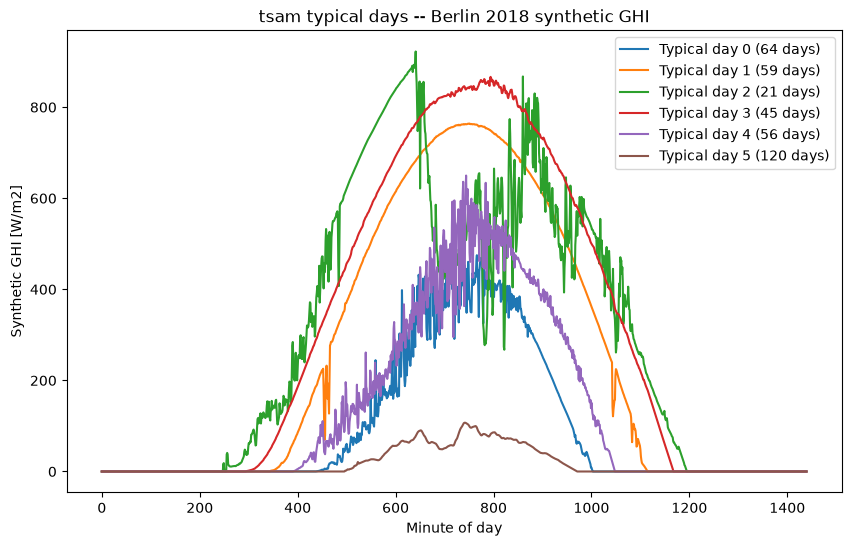

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for cluster_id, day_profile in aggregated.cluster_representatives.groupby(level=0):
    ax.plot(
        range(len(day_profile)),
        day_profile["synthetic_ghi"].values,
        label=f"Typical day {cluster_id} ({aggregated.cluster_counts[cluster_id]:.0f} days)",
    )

ax.set_xlabel("Minute of day")
ax.set_ylabel("Synthetic GHI [W/m2]")
ax.set_title("tsam typical days -- Berlin 2018 synthetic GHI")
ax.legend()
plt.show()